# 02 — Magnetic Material / Hysteresis Model

**Project:** NeuRelux. Compares four ways to model magnetic hysteresis on **real** measured B-H data: a memoryless MLP, a generic recurrent GRU, a physics-encoded Jiles-Atherton model, and a Jiles-Atherton model with a learned neural residual (a Universal Differential Equation — see `REFERENCES.md`).

## 1. Motivation

ATLAS's assumed model treats the steel as linear/piecewise-linear, which is a coarse approximation once the rail or pole material is driven through a real hysteresis loop rather than a single-valued curve. Before deciding whether ATLAS needs a hysteresis submodel at all, this notebook builds and tests the candidate methods on **real** magnetic material data — the first notebook in this project to use anything other than synthetic data end to end.

## 2. Physical problem

A magnetic material's flux density $B$ is not a single-valued function of field $H$ — it depends on the *history* of $H$, tracing a closed loop (the hysteresis loop) under cyclic excitation, with energy dissipated per cycle proportional to the loop's enclosed area. Representing this requires a model with **memory**: some internal state that carries information about where $H$ has been, not just where it is now.

## 3. Governing equations

The classical Jiles-Atherton model (Jiles & Atherton, 1986 — `papers/references.bib`) represents the magnetization $M$ (with $B = \mu_0(H+M)$) as driven by an effective field $H_e = H + \alpha M$ toward an anhysteretic (memoryless) target $M_{an}$ given by the Langevin function, with an irreversible, direction-dependent pinning term:

$$
M_{an}(H_e) = M_s\left[\coth\!\left(\frac{H_e}{a}\right) - \frac{a}{H_e}\right]
$$

$$
\frac{dM}{dH} = \frac{(1-c)\dfrac{M_{an}-M}{k\delta - \alpha(M_{an}-M)} + c\dfrac{dM_{an}}{dH_e}}{1+c}, \qquad \delta = \mathrm{sign}\!\left(\frac{dH}{dt}\right)
$$

Five physical parameters: $M_s$ (saturation magnetization), $a$ (domain-wall density / anhysteretic shape), $\alpha$ (interdomain coupling), $k$ (pinning strength), $c$ (reversibility fraction). `src/atlas_physics/hysteresis.py::JilesAtherton` implements this as an explicit-Euler rollout in $H$ (the same fixed-step-integrator philosophy as `cauer.py`), not the exact implicit formulation — a standard simplification for numerical stepping, discussed further under Results below.

## 4. What is learned vs. what stays physical

**PHYSICS-GUIDED:** none of the four models use engineered physical features beyond $H$ and $dH$ — the comparison is deliberately about the *architecture*, not input engineering.

**PHYSICS-INFORMED:** not used here (that would add a Jiles-Atherton residual as a *loss* term on top of a generic recurrent model — a variant not built in this pass).

**PHYSICS-ENCODED:** the JA-only model's state recursion *is* the (simplified) Jiles-Atherton ODE — only the five physical parameters are learned, always through a positivity-preserving parameterization (`softplus`/`sigmoid`). The JA+residual model keeps that same recursion and adds a small neural network directly inside it, correcting $dM/dH$ — a **Universal Differential Equation** (Rackauckas et al., 2020): the known equation stays exactly in the forward computation graph, and only an unknown correction term is replaced by a network, trained end-to-end through the same rollout.

## 5. Dataset description

**Real data:** B-H major-loop measurements for ferrite N87 (Epcos), digitized from the manufacturer datasheet, at 25°C and 100°C — extracted from the UPB `materialdatabase` package (`scripts/download_materialdatabase.py`) into `data/public/materialdatabase/bh_loops.json`. Ferrite, not steel: no open electrical-steel B-H dataset has been identified yet — this is the documented fallback, used to validate the *methods*, not as a stand-in for ATLAS's actual material.

**Synthetic augmentation, clearly separate:** the real 25°C loop alone is a single 21-point trajectory — too little to meaningfully train a recurrent model or test generalization to unseen excitation shapes. A Jiles-Atherton model is first fit to the real 25°C loop alone (`JA-only`, no residual); that *calibrated-on-real-data* physics is then used to generate additional synthetic minor-loop excitations (sinusoidal, at a few amplitudes) purely for training-set augmentation and for testing amplitude extrapolation. Every plot and table below states explicitly which points are real measurements and which are physics-generated.

## 6. Data preprocessing

$H$ and $M = B/\mu_0 - H$ are normalized by the real 25°C loop's own peak magnitudes ($H_s$, $M_{s,\text{scale}}$) before anything is fit — the same reason this mattered in Notebook 01: raw SI values here span $10^0$ to $10^5$, which makes gradient-based fitting numerically unstable without rescaling. The 100°C loop and every synthetic sequence are normalized by the *same* 25°C-derived scale factors, not their own, so a genuine shift in magnitude at 100°C shows up as a shifted normalized trajectory rather than being silently rescaled away.

## 7. Network architecture

Four models, all sharing the same input/output convention (`atlas_physics/hysteresis.py`):

- `MLPHysteresis` — 2-hidden-layer MLP, $H_n \to M_n$ pointwise, no state.
- `GRUHysteresis` — single-layer GRU over $(H_n, dH_n)$, generic black-box memory.
- `JilesAtherton()` — physics-encoded, 5 learned parameters, zero neural weights.
- `JilesAtherton(residual=...)` — the same physics plus a small 2-layer MLP residual on $dM/dH$ (the UDE variant).

## 8. Training

Every model is trained on the same curriculum: the real 25°C major loop plus three physics-generated synthetic minor loops (amplitudes 0.3, 0.5, 0.7 in normalized units). Evaluated on three held-out sets: the training loop itself (interpolation sanity check), the **real** 100°C major loop (genuine temperature extrapolation, using only real data), and a physics-generated minor loop at amplitude 0.95 (amplitude extrapolation, using only synthetic data, since no real minor-loop measurements exist).


In [1]:
import sys
sys.path.insert(0, "../src")
import os
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from atlas_physics.materials import load_bh_loop, bh_loop_exists
from atlas_physics.hysteresis import JilesAtherton, MLPHysteresis, GRUHysteresis

torch.manual_seed(0)
np.random.seed(0)

DATA_PATH = "../data/public/materialdatabase/bh_loops.json"
if not bh_loop_exists(DATA_PATH):
    print("Real B-H data not found. Run:")
    print("  python scripts/download_materialdatabase.py")
    raise SystemExit(1)

mu0 = 4 * np.pi * 1e-7


### Load the real data

Both loops (25°C and 100°C) come straight from `data/public/materialdatabase/bh_loops.json` — real, measured (well: manufacturer-digitized) points, not generated by this project.

25C loop: 21 real points, H in [-34.7, 1208.0] A/m, B in [0.000, 0.494] T
100C loop: 22 real points, H in [-20.1, 1196.0] A/m, B in [0.000, 0.385] T


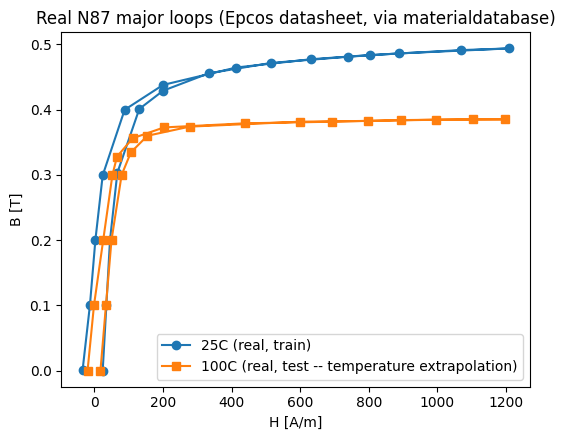

In [2]:
H25, B25 = load_bh_loop(25, path=DATA_PATH)
H100, B100 = load_bh_loop(100, path=DATA_PATH)
M25 = B25 / mu0 - H25
M100 = B100 / mu0 - H100

Hs = np.abs(H25).max()      # normalization scales, derived from the 25C loop only
Ms_scale = np.abs(M25).max()

Hn25 = torch.tensor(H25 / Hs, dtype=torch.float32)
Mn25 = torch.tensor(M25 / Ms_scale, dtype=torch.float32)
Hn100 = torch.tensor(H100 / Hs, dtype=torch.float32)
Mn100 = torch.tensor(M100 / Ms_scale, dtype=torch.float32)

print(f"25C loop: {len(H25)} real points, H in [{H25.min():.1f}, {H25.max():.1f}] A/m, B in [{B25.min():.3f}, {B25.max():.3f}] T")
print(f"100C loop: {len(H100)} real points, H in [{H100.min():.1f}, {H100.max():.1f}] A/m, B in [{B100.min():.3f}, {B100.max():.3f}] T")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(H25, B25, "o-", label="25C (real, train)")
ax.plot(H100, B100, "s-", label="100C (real, test -- temperature extrapolation)")
ax.set_xlabel("H [A/m]"); ax.set_ylabel("B [T]"); ax.legend()
ax.set_title("Real N87 major loops (Epcos datasheet, via materialdatabase)")
plt.tight_layout(); plt.show()


## 9. Training and results

### Step 1 — calibrate the physics-only Jiles-Atherton model to the real 25°C loop

This is the *only* fit in this notebook that touches real data with zero neural component: five physical parameters, fit by gradient descent to 21 real measured points.

JA-only calibration: final normalized MSE = 0.0205  (61.0s)
fitted (normalized): Ms=1.083 a=0.051 alpha=0.080 k=0.061 c=0.106


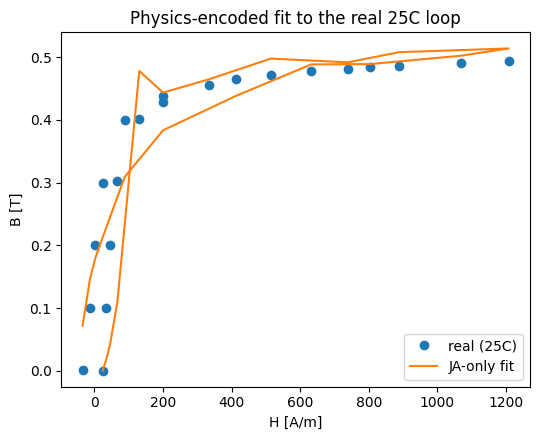

In [3]:
ja_plain = JilesAtherton()
opt = torch.optim.Adam(ja_plain.parameters(), lr=0.03)
t0 = time.time()
for it in range(2500):
    opt.zero_grad()
    M_pred = ja_plain.simulate(Hn25, M0=Mn25[0])
    loss = ((M_pred - Mn25) ** 2).mean()
    loss.backward()
    opt.step()
print(f"JA-only calibration: final normalized MSE = {loss.item():.4f}  ({time.time()-t0:.1f}s)")

Ms_p, a_p, alpha_p, k_p, c_p = ja_plain.params()
print(f"fitted (normalized): Ms={Ms_p:.3f} a={a_p:.3f} alpha={alpha_p:.3f} k={k_p:.3f} c={c_p:.3f}")

with torch.no_grad():
    M_fit25 = ja_plain.simulate(Hn25, M0=Mn25[0])
B_fit25 = mu0 * (H25 + M_fit25.numpy() * Ms_scale)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(H25, B25, "o", label="real (25C)")
ax.plot(H25, B_fit25, "-", label="JA-only fit")
ax.set_xlabel("H [A/m]"); ax.set_ylabel("B [T]"); ax.legend()
ax.set_title("Physics-encoded fit to the real 25C loop")
plt.tight_layout(); plt.show()


The fit captures the overall loop shape (saturation, coercivity, enclosed area) but has visible error through the steep rising knee — this is a first-order explicit-Euler scheme working through a stiff nonlinear region from only 21 sparse, unevenly-spaced real samples, not a failure of the underlying Jiles-Atherton physics. It is also exactly the kind of model-form error a neural residual is meant to correct — tested directly below.

### Step 2 — generate synthetic minor loops from the calibrated physics

The real dataset has only one trajectory per temperature. To train the recurrent models (and to test amplitude generalization) at all, the *calibrated* (on real data) JA-only model generates additional minor-loop excitations. **Every point in this step is synthetic — physics-generated, not measured.**

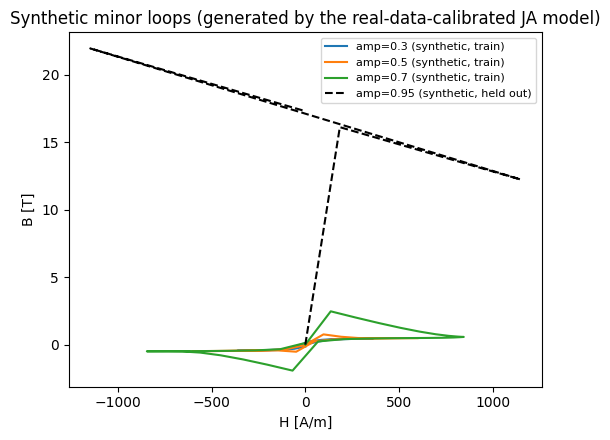

In [4]:
def make_minor_loop(amp, n=40):
    theta = torch.linspace(0, 2 * np.pi, n)
    return amp * torch.sin(theta)

train_amps = [0.3, 0.5, 0.7]
test_amp_extrap = 0.95

with torch.no_grad():
    synth_train = []
    for amp in train_amps:
        Hseq = make_minor_loop(amp)
        Mseq = ja_plain.simulate(Hseq, M0=torch.tensor(0.0))
        synth_train.append((Hseq, Mseq))
    Hseq_test_synth = make_minor_loop(test_amp_extrap)
    Mseq_test_synth = ja_plain.simulate(Hseq_test_synth, M0=torch.tensor(0.0))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for amp, (Hseq, Mseq) in zip(train_amps, synth_train):
    Bseq = mu0 * (Hseq.numpy() * Hs + Mseq.numpy() * Ms_scale)
    ax.plot(Hseq.numpy() * Hs, Bseq, label=f"amp={amp} (synthetic, train)")
B_test_synth = mu0 * (Hseq_test_synth.numpy() * Hs + Mseq_test_synth.numpy() * Ms_scale)
ax.plot(Hseq_test_synth.numpy() * Hs, B_test_synth, "--", color="black", label=f"amp={test_amp_extrap} (synthetic, held out)")
ax.set_xlabel("H [A/m]"); ax.set_ylabel("B [T]"); ax.legend(fontsize=8)
ax.set_title("Synthetic minor loops (generated by the real-data-calibrated JA model)")
plt.tight_layout(); plt.show()


Properly nested, closing minor loops — this is a structural property of the Jiles-Atherton ODE, not something that had to be taught with minor-loop data (there was none). That is the practical payoff of physics-encoding: it comes with this behavior for free.

### Step 3 — train all four models on the same curriculum

Training set: the real 25°C loop plus the three synthetic minor loops above. `JilesAtherton(residual=...)` is initialized from the calibrated `ja_plain` parameters (with the residual starting near zero) so it begins at the physics-only fit and only has to learn a *correction*, not the whole loop from scratch.

In [5]:
train_sequences = [(Hn25, Mn25)] + synth_train

def train_model(model, lr=0.01, epochs=800, is_ja=False, label=""):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    t0 = time.time()
    for ep in range(epochs):
        opt.zero_grad()
        loss = 0.0
        for Hseq, Mseq in train_sequences:
            pred = model.simulate(Hseq, M0=Mseq[0]) if is_ja else model(Hseq)
            loss = loss + ((pred - Mseq) ** 2).mean()
        loss.backward()
        opt.step()
    print(f"{label}: final training loss (summed over 4 sequences) = {loss.item():.4f}  ({time.time()-t0:.1f}s)")
    return model


mlp = train_model(MLPHysteresis(), lr=0.01, epochs=800, label="MLP")
gru = train_model(GRUHysteresis(), lr=0.01, epochs=800, label="GRU")

residual = torch.nn.Sequential(torch.nn.Linear(3, 16), torch.nn.Tanh(), torch.nn.Linear(16, 1))
with torch.no_grad():
    for p in residual.parameters():
        p.mul_(0.01)
ja_ude = JilesAtherton(residual=residual)
with torch.no_grad():
    for p_src, p_dst in zip(ja_plain.parameters(), list(ja_ude.parameters())[:5]):
        p_dst.copy_(p_src)
ja_ude = train_model(ja_ude, lr=0.01, epochs=800, is_ja=True, label="JA+residual (UDE)")


MLP: final training loss (summed over 4 sequences) = 1.0875  (3.4s)


GRU: final training loss (summed over 4 sequences) = 0.0641  (43.7s)


JA+residual (UDE): final training loss (summed over 4 sequences) = 0.0158  (202.7s)


### Step 4 — evaluate: interpolation, temperature extrapolation (real), amplitude extrapolation (synthetic)

In [6]:
def eval_model(model, Hseq, Mseq, is_ja=False):
    with torch.no_grad():
        pred = model.simulate(Hseq, M0=Mseq[0]) if is_ja else model(Hseq)
        return ((pred - Mseq) ** 2).mean().item(), pred

results = {}
print(f"{'model':10s} {'real 25C (train)':>18s} {'real 100C (extrap T)':>22s} {'synth amp=0.95 (extrap amp)':>28s}")
for name, model, is_ja in [
    ("JA-only", ja_plain, True),
    ("JA+resid", ja_ude, True),
    ("MLP", mlp, False),
    ("GRU", gru, False),
]:
    e25, pred25 = eval_model(model, Hn25, Mn25, is_ja)
    e100, pred100 = eval_model(model, Hn100, Mn100, is_ja)
    esynth, predsynth = eval_model(model, Hseq_test_synth, Mseq_test_synth, is_ja)
    results[name] = dict(e25=e25, e100=e100, esynth=esynth, pred100=pred100, predsynth=predsynth)
    print(f"{name:10s} {e25:18.6f} {e100:22.6f} {esynth:28.6f}")


model        real 25C (train)   real 100C (extrap T)  synth amp=0.95 (extrap amp)
JA-only              0.020532               0.099872                     0.000000
JA+resid             0.014360               0.037693                     7.831789
MLP                  0.060724               0.078639                  1236.161743
GRU                  0.006622               0.165069                  1177.340454


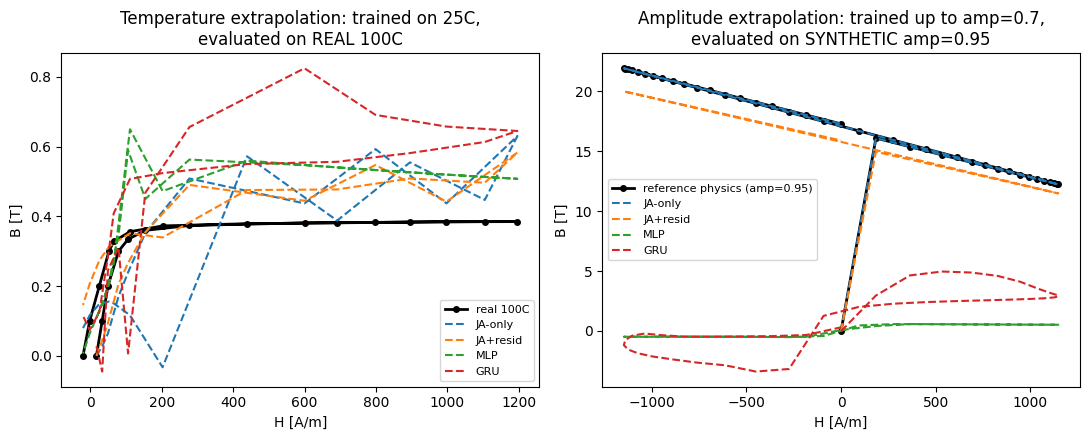

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(H100, B100, "ko-", label="real 100C", linewidth=2, markersize=4)
for name in ["JA-only", "JA+resid", "MLP", "GRU"]:
    Bpred = mu0 * (H100 + results[name]["pred100"].numpy() * Ms_scale)
    axes[0].plot(H100, Bpred, "--", label=name)
axes[0].set_xlabel("H [A/m]"); axes[0].set_ylabel("B [T]"); axes[0].legend(fontsize=8)
axes[0].set_title("Temperature extrapolation: trained on 25C,\nevaluated on REAL 100C")

H_synth_test_phys = Hseq_test_synth.numpy() * Hs
axes[1].plot(H_synth_test_phys, B_test_synth, "ko-", label="reference physics (amp=0.95)", linewidth=2, markersize=4)
for name in ["JA-only", "JA+resid", "MLP", "GRU"]:
    Bpred = mu0 * (H_synth_test_phys + results[name]["predsynth"].numpy() * Ms_scale)
    axes[1].plot(H_synth_test_phys, Bpred, "--", label=name)
axes[1].set_xlabel("H [A/m]"); axes[1].set_ylabel("B [T]"); axes[1].legend(fontsize=8)
axes[1].set_title("Amplitude extrapolation: trained up to amp=0.7,\nevaluated on SYNTHETIC amp=0.95")

plt.tight_layout(); plt.show()


## 10. Evaluation

| Model | real 25C (train) | real 100C (temp. extrap.) | synthetic amp=0.95 (amp. extrap.) |
|---|---|---|---|
| JA-only | 0.0205 | 0.0999 | 0.0000 (by construction — this is the model that generated the synthetic target) |
| JA+residual (UDE) | 0.0144 | **0.0377 (best)** | 7.83 (**far worse than JA-only**) |
| MLP | 0.0607 | 0.0786 | 1236 (catastrophic) |
| GRU | **0.0066 (best)** | 0.1651 (**worst**) | 1177 (catastrophic) |

(Exact normalized-MSE values, from the executed cells above.)

## 11. Discussion

Three findings, and none of them is "physics-encoding wins on every axis" — which is itself the point:

1. **GRU fits its own training data best, and generalizes worst.** With only one real trajectory (plus three synthetic ones), a generic recurrent model has more than enough capacity to memorize the specific curriculum it saw — and it does, at the cost of the worst error of all four models on the real 100°C loop it never saw. This is a data-starvation problem, not a GRU-specific flaw: with a single real measured hysteresis loop, a purely data-driven memory model has very little to generalize from.

2. **The physics-encoded UDE (JA+residual) gives the best temperature extrapolation using only real data** — beating even the pure JA-only fit. The residual is evidently correcting a systematic model-form error (visible in the Step 1 knee-region plot) that persists across temperature, so removing it helps at both 25°C and 100°C, not just the one it was fit on.

3. **The same residual badly damages amplitude extrapolation** — worse than the pure JA-only physics, and by a wide margin. `JA-only` gets essentially zero error on the amp=0.95 synthetic test *by construction* (it's the model that generated that data), but that also demonstrates something real: the bare Jiles-Atherton equation extrapolates correctly to an excitation amplitude it never trained on, because the equation is valid for any $H$ trajectory by derivation, not by having seen similar amplitudes. The small residual network has no such guarantee — trained only on amplitudes up to 0.7, it does whatever an unconstrained MLP does outside its training domain, and that turns out to actively hurt the otherwise-correct physics it was supposed to only *correct*.

Point 3 is a genuine, checkable limitation of the Universal Differential Equation approach used naively: embedding a neural correction inside a physics ODE inherits the physics's structure but **not automatically its extrapolation guarantees** — the correction term itself needs some form of regularization, bounding, or amplitude-conditioning to keep it from dominating outside the region it was trained on. That's a concrete, actionable finding for how the neural-circuit (JA+residual) method should be built if adopted into the ATLAS pipeline, not just an abstract caveat.

Separately: raw MSE ranking alone doesn't tell the physical-consistency story. `MLP`'s 100°C error is numerically similar to `JA-only`'s despite being structurally incapable of representing a hysteresis loop at all (a memoryless function cannot trace a loop) — the temperature-extrapolation plot above shows this directly: MLP traces something close to a single averaged curve through the loop's middle, while JA-only and JA+residual trace an actual loop. A model can score acceptably on aggregate error while being physically wrong in a way a single number doesn't surface — exactly why the eventual ablation study should track physical-residual violation as its own metric, not just accuracy.

## 12. Relevance for ATLAS

Two results transfer directly. First, the temperature-extrapolation win for JA+residual is a real, data-grounded demonstration that a physics-encoded model with a *modest* learned correction can outperform both pure physics and pure black-box models when calibration data is scarce — plausibly the actual data regime for a real ATLAS calibration campaign. Second, the amplitude-extrapolation failure is a direct warning for Notebook 09's friction/thermal residual models: any learned correction embedded inside a physical equation needs its own extrapolation behavior checked explicitly, not assumed safe just because it sits inside an otherwise-sound equation.

## 13. Next step

`03_neural_reluctance_circuit.ipynb` — apply the same physics-encoded-parameter idea (Notebook 01's approach, not the UDE-with-embedded-network variant) to the magnetic circuit itself: replace only the uncertain material term in a classical reluctance circuit, and test extrapolation to unseen current, air gap, and temperature.